# Question from COO
### Which products had negative comments related to the shipping and delivery?

In [81]:
import pandas as pd

# Getting products data only 60000 rows
df_reviews = pd.read_csv('../data/BaSalam.reviews.csv', nrows=60000)
pd.set_option("display.max_columns", None)

df_reviews.head()

,_id,productId,star,user_id,isPost,isPublic,id,createdAt,updatedAt,hashId,isPosted,isLikedByCurrentUser,isDislikedByCurrentUser,likeCount,dislikeCount,attachments,history_count,user_id_of_user,name_of_user,hash_id_of_user,photo_of_user,description,reason_ids[0],reason_ids[1],reason_ids[2],reason_ids[3],reason_ids[4],reason_ids[5],reason_ids[6],reason_ids[7],variation_metadata
0,661ba7096a6e1c5d7e653541,824662,5,15127771,False,True,11220580,2024-04-03T23:45:57,2024-04-03T23:45:57,rBNa53,False,False,False,0,0,"{'photos': [], 'video': None}",1,15127771,nima yoshij,zMlyjw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,661ba7096a6e1c5d7e653542,824662,5,2695119,False,True,11219739,2024-04-03T22:49:50,2024-04-03T22:49:50,joZjyb,False,False,False,0,0,"{'photos': [], 'video': None}",3,2695119,مهدی حمزه نژادی،تجربه خرید مطمئن 🙏🌹,EK52K,{'LARGE': 'https://statics.basalam.com/public/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,661ba7096a6e1c5d7e653543,824662,5,11408497,False,True,11219258,2024-04-03T22:19:06,2024-04-03T22:19:06,GxNEX2,False,False,False,0,0,"{'photos': [], 'video': None}",1,11408497,محمد اوجی,1wd43d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,661ba7096a6e1c5d7e653544,824662,5,482919,False,True,11216410,2024-04-03T19:49:25,2024-04-03T19:49:25,dN8rzl,False,False,False,0,0,"{'photos': [], 'video': None}",1,482919,براتی,EGznn,NaN,عالییییه،دو بار سفارش زدم تا حالا,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,661ba7096a6e1c5d7e653545,824662,5,4427128,False,True,11211517,2024-04-03T15:50:37,2024-04-03T15:50:37,KW3nQa,False,False,False,0,0,"{'photos': [], 'video': None}",1,4427128,آرسام,8MqwA4,{'LARGE': 'https://statics.basalam.com/public/...,سپاس،تازه و خوشمزه و با کیفیت هست,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# Removing columns that has more than 300 NaN values 
df_reviews = df_reviews.dropna(axis=1, thresh=300)

In [14]:
df_reviews.columns

Index(['_id', 'productId', 'star', 'user_id', 'isPost', 'isPublic', 'id',
       'createdAt', 'updatedAt', 'hashId', 'isPosted', 'isLikedByCurrentUser',
       'isDislikedByCurrentUser', 'likeCount', 'dislikeCount', 'attachments',
       'history_count', 'user_id_of_user', 'name_of_user', 'hash_id_of_user',
       'photo_of_user', 'description'],
      dtype='str')

In [83]:
# Removing all useless columns
df_reviews = df_reviews.drop(columns=['photo_of_user','hash_id_of_user','history_count','attachments','isDislikedByCurrentUser','isLikedByCurrentUser','hashId','updatedAt','createdAt','isPublic'])

In [84]:
# Users who weren't satisfied (bad reviews in comments)
df_bad_reviews = df_reviews[df_reviews['star'] <= 3]

In [85]:
# importing product table
df_products = pd.read_csv('../data/BaSalam.products.csv',nrows=100000)

df_products.head()

/tmp/ipykernel_16215/3273149625.py:2: DtypeWarning: Columns (0: mainAttribute, 1: promotions) have mixed types. Specify dtype option on import or set low_memory=False.
  df_products = pd.read_csv('../data/BaSalam.products.csv',nrows=100000)


,_id,_score,sales_count_week,name,price,status_id,status_title,stock,photo_MEDIUM,photo_SMALL,rating_average,rating_count,rating_signals,primaryPrice,preparationDays,weight,categoryId,has_delivery,has_variation,new_categoryId,navigation_id,vendor_name,vendor_identifier,vendor_statusId,vendor_freeShippingToIran,vendor_freeShippingToSameCity,vendor_cityId,vendor_provinceId,vendor_has_delivery,vendor_score,vendor_id,vendor_status_id,vendor_status_title,vendor_owner_city,vendor_owner_id,isFreeShipping,IsAvailable,IsSaleable,mainAttribute,categoryTitle,published,video_ORIGINAL,promotions
0,9873883,468.75000,14,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000,2976,در دسترس,746,https://statics.basalam.com/public-17/users/Pe...,https://statics.basalam.com/public-17/users/Pe...,4.7,80,80,6000000,5,1000,0.0,True,False,191,2032.0,فروشگاه بزرگ برتر(ارسال رایگان باخرید760هزار),khoshkbarbartar,2987,7600000.0,2970000.0,2143,12,True,0.0,783928,2987,فعال,قاین,13052433,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN
1,21808,466.66666,13,روغن زیتون فدک 1 لیتری مزرعه ارگانیک فدک سید ا...,6600000,2976,در دسترس,4,https://statics.basalam.com/public-3/users/J2/...,https://statics.basalam.com/public-3/users/J2/...,4.9,1480,1480,0,1,900,160.0,True,False,154,NaN,مزرعه زیتون فدک سید احمد بلندنظر,fadak,2987,NaN,NaN,2531,21,True,1.0,15,2987,فعال,قم,20,False,True,True,900 گرم,روغن‌های خوراکی,True,https://basalam-com.arvanvod.ir/yOpvGE3e0D/x3Q...,NaN
2,10215970,464.28570,12,عناب درجه یک بیرجند یک کیلویی. تضمین کیفیت و ...,1360000,2976,در دسترس,813,https://statics.basalam.com/public-13/users/Pe...,https://statics.basalam.com/public-13/users/Pe...,5.0,41,41,1650000,5,1000,0.0,True,False,191,NaN,فروشگاه بزرگ برتر(ارسال رایگان باخرید760هزار),khoshkbarbartar,2987,7600000.0,2970000.0,2143,12,True,0.0,783928,2987,فعال,قاین,13052433,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN
3,11061637,461.53845,11,هل سبز اکبر بنفش50گرمی. سبز ودرشت وبسیار معطر,1054000,2976,در دسترس,1708,https://statics.basalam.com/public-14/users/ME...,https://statics.basalam.com/public-14/users/ME...,5.0,8,8,1250000,5,50,0.0,True,False,133,NaN,زرشک وزعفران برتر قاینات,intertopme,2987,5870000.0,37000.0,2143,12,True,1.0,369193,2987,فعال,قاین,1145924,False,True,True,50 گرم,ادویه,NaN,NaN,NaN
4,10843522,461.53845,11,زرشک دانه اناری اعلا 1402(یک کیلویی).محصول تضم...,1830000,2976,در دسترس,1509,https://statics.basalam.com/public-16/users/LZ...,https://statics.basalam.com/public-16/users/LZ...,4.9,34,34,2100000,5,1000,0.0,True,False,191,NaN,خشکبار تواضع(ارسال رایگان باخرید847هزار),narmilatak,2987,8470000.0,5470000.0,2143,12,True,1.0,814012,2987,فعال,قاین,1246369,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN


In [86]:
# merging 2 columns to have a better view that who gave bad reviews to which product(JOINING 2 tables)


merged_df = pd.merge(
    df_bad_reviews,
    df_products[['_id','name','price']],
    left_on='productId',
    right_on='_id',
    how='left'
)


In [87]:
# remonig NaN rows from name column
merged_df = merged_df.dropna(subset=['name'])
merged_df.info()

<class 'pandas.DataFrame'>
Index: 2546 entries, 62 to 5153
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   _id_x            2546 non-null   str    
 1   productId        2546 non-null   int64  
 2   star             2546 non-null   int64  
 3   user_id          2546 non-null   int64  
 4   isPost           2546 non-null   bool   
 5   id               2546 non-null   int64  
 6   isPosted         2438 non-null   object 
 7   likeCount        2546 non-null   int64  
 8   dislikeCount     2546 non-null   int64  
 9   user_id_of_user  2546 non-null   int64  
 10  name_of_user     2546 non-null   str    
 11  description      1490 non-null   str    
 12  reason_ids[0]    96 non-null     float64
 13  reason_ids[1]    56 non-null     float64
 14  reason_ids[2]    22 non-null     float64
 15  reason_ids[3]    3 non-null      float64
 16  _id_y            2546 non-null   float64
 17  name             2546 non-nul

In [88]:
merged_df

,_id_x,productId,star,user_id,isPost,id,isPosted,likeCount,dislikeCount,user_id_of_user,name_of_user,description,reason_ids[0],reason_ids[1],reason_ids[2],reason_ids[3],_id_y,name,price
62,661ba7096a6e1c5d7e6537a4,9873883,3,4809406,False,11006334,False,0,0,4809406,احسان زمانی,NaN,NaN,NaN,NaN,NaN,9873883.0,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000.0
63,661ba7096a6e1c5d7e6537a6,9873883,3,11542303,False,10817088,False,0,0,11542303,محمود جمالی,با عکسش فرق داره.یه مقدار کدره,NaN,NaN,NaN,NaN,9873883.0,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000.0
64,661ba7096a6e1c5d7e6537a8,9873883,3,4712583,False,10500639,False,0,0,4712583,جواد ابراهیمی,NaN,NaN,NaN,NaN,NaN,9873883.0,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000.0
65,661ba7096a6e1c5d7e6537ac,9873883,3,376357,False,10323949,False,0,0,376357,حسین جبلی,سلام خدمت دوستان عزیز .پسته خوش طعمی است به شم...,NaN,NaN,NaN,NaN,9873883.0,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000.0
66,661ba7096a6e1c5d7e6537b6,9873883,3,7666022,False,9494616,False,1,0,7666022,حميده طهماسبى,سلام بد نبود ولی زعفرانی نبود .یه کم کوچیکه..ن...,NaN,NaN,NaN,NaN,9873883.0,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5149,661ba71a6a6e1c5d7e661f75,407440,2,10464133,False,7905300,False,0,0,10464133,محمد شفیعی,خوش خوراک نیست کمی سفته,NaN,NaN,NaN,NaN,407440.0,قند شکسته سنتی یزد ( 4/5 کیلویی ) بدون جوهر (ا...,3101000.0
5150,661ba71a6a6e1c5d7e661f81,407440,2,7788899,False,5742691,False,0,0,7788899,خانم فرخ السادات ابوتراب,با سلام چرا رنگ قند روشن نیست,NaN,NaN,NaN,NaN,407440.0,قند شکسته سنتی یزد ( 4/5 کیلویی ) بدون جوهر (ا...,3101000.0
5151,661ba71a6a6e1c5d7e661f84,407440,1,103297,False,4668224,False,0,0,103297,Ghasem,افتضاح ! قند خیس و بد بو ! دروغ محض که قند یزده !,NaN,NaN,NaN,NaN,407440.0,قند شکسته سنتی یزد ( 4/5 کیلویی ) بدون جوهر (ا...,3101000.0
5152,661ba71a6a6e1c5d7e661f90,407440,3,7644962,False,3462309,False,0,0,7644962,سیدحسین بهادر,قند خیلی خوب وسفیدومرغوبی است فقط ارسالش طول م...,NaN,NaN,NaN,NaN,407440.0,قند شکسته سنتی یزد ( 4/5 کیلویی ) بدون جوهر (ا...,3101000.0


In [ ]:
# creating keywords related to the posting and delivery
shipping_keywords = ['ارسال', 'پست', 'دیر', 'تیپاکس', 'بسته', 'رعایت', 'مامور']

# making sure that comments are not null
merged_df['description'] = merged_df['description'].fillna('')

# filtering the comment by those keywords
shipping_issues_df = merged_df[
    merged_df['description'].str.contains('|'.join(shipping_keywords), na=False) & 
    (merged_df['star'] <= 2)
]


تعداد کامنت‌های منفی مربوط به ارسال: 179


In [93]:
# شمارش تعداد کامنت‌های منفیِ ارسال برای هر محصول
bad_products_summary = shipping_issues_df['name'].value_counts().reset_index()
bad_products_summary.columns = ['product_name', 'negative_shipping_count']

bad_products_summary

,product_name,negative_shipping_count
0,تخمه ایرانی ارسال رایگان میشه باخرید 2کیلوگرم ...,3
1,تخم شترمرغ گرم وتازه، خوراکی,3
2,توت خشک ریز طبیعی امسالی(یک کیلو) توت ریز,3
3,کمپوت تیکه آناناس 565 گرمی,3
4,کیمچی کاهو,2
...,...,...
151,آلو بخارا,1
152,هل اکبر بنفش50 گرمی چاشنی خاتون,1
153,کشک محلی گوسفندی درجه یک عسل فروشی عبدی,1
154,کلمپه (کلوچه) خرمایی دارچین نرم تازه(یک کیلو),1


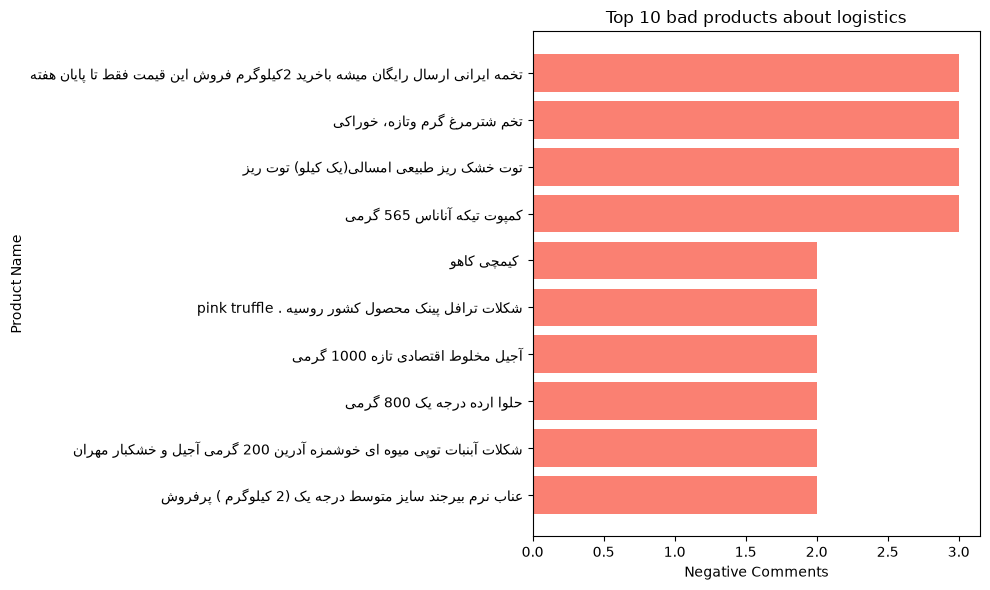

In [105]:
import matplotlib.pyplot as plt

top_bad_products = bad_products_summary.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_bad_products['product_name'], top_bad_products['negative_shipping_count'], color='salmon')

plt.title('Top 10 bad products about logistics')
plt.xlabel('Negative Comments')
plt.ylabel('Product Name')

plt.gca().invert_yaxis()
plt.tight_layout()


plt.savefig('../outputs/top_10_bad_products_logistics', dpi=300)